Performing a comparison of the 10kb bed of reference coordinates and lifted, using best case (Cercopithecus) and worst case (Lepilemur).

In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
for bed_path in glob.glob("../results/window_stats_20x_inds/*_10kb_pi.bed"):
    long_form = bed_path.split("/")[-1].split("_10kb")[0]
    bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
    bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
    bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)
    print(long_form, bed_df.callable_frac.mean())

Chlorocebus_pygerythrus_ssp 0.9283734457158923
Cebuella_pygmaea_ssp 0.9030860208408502
Pygathrix_nemaeus_ssp 0.8704107002894262
Macaca_cyclopis_ssp 0.9487567681582804
Saguinus_mystax_ssp 0.8140816907857086
Alouatta_juara_ssp 0.7915587695203703
Lepilemur_dorsalis_ssp 0.5847897241370876
Cercopithecus_mona_ssp 0.9524683597018152
Microcebus_jonahi_ssp 0.7909292130114569
Macaca_sylvanus_ssp 0.9132915443541724
Chlorocebus_dryas_ssp 0.8985333994757343
Trachypithecus_germaini_ssp 0.9277920986929062
Cercocebus_chrysogaster_ssp 0.8954961610827223
Eulemur_collaris_ssp 0.9407738150257713
Pan_paniscus_ssp 0.8519756130304168
Daubentonia_madagascariensis_ssp 0.9905407861514366
Plecturocebus_bernhardi_ssp 0.9562908380098234
Chiropotes_israelita_ssp 0.9071620992018385
Ateles_geoffroyi_ssp 0.8998155290855959
Trachypithecus_phayrei_ssp 0.9360563327005051
Eulemur_rubriventer_ssp 0.9537361028700163
Semnopithecus_entellus_ssp 0.9248975705775518
Leontopithecus_rosalia_ssp 0.9845161403824276
Saimiri_oerstedii

Trachypithecus_pileatus_ssp 0.9005597204510608
Symphalangus_syndactylus_ssp 0.8329028624295257
Saguinus_inustus_ssp 0.8114246150223069
Callithrix_kuhlii_ssp 0.8759792531342643
Rhinopithecus_avunculus_ssp 0.7334567435025487
Presbytis_comata_ssp 0.8402570813950727
Cebus_unicolor_ssp 0.9418696308186197
Pithecia_chrysocephala_ssp 0.9720765356127256
Plecturocebus_cupreus_ssp 0.9686354675628074
Trachypithecus_cristatus_ssp 0.9239260892303833
Gorilla_beringei_ssp 0.797584485933445
Pygathrix_nigripes_ssp 0.8598712567434601
Trachypithecus_obscurus_ssp 0.9288014951463268
Trachypithecus_vetulus_ssp 0.9229949891816763
Cheracebus_lucifer_ssp 0.8774230687881378
Semnopithecus_schistaceus_ssp 0.9161023291636218
Trachypithecus_johnii_ssp 0.9218158091185236
Aotus_griseimembra_ssp 0.9296040020697812
Trachypithecus_francoisi_ssp 0.9612522830093384
Varecia_variegata_ssp 0.980294385484607
Theropithecus_gelada_ssp 0.965682894398767
Carlito_syrichta_ssp 0.8338228695360136
Cacajao_melanocephalus_ssp 0.90833266

Surprising that macaca is slightly worse, but this is also very depdendant on depth and number of samples used.

In [4]:
bed_path = "../results/window_stats_20x_inds/{}_10kb_pi.bed".format("Arctocebus_calabarensis_ssp")
long_form = bed_path.split("/")[-1].split("_10kb")[0]
bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)

<Axes: xlabel='callable_frac', ylabel='Count'>

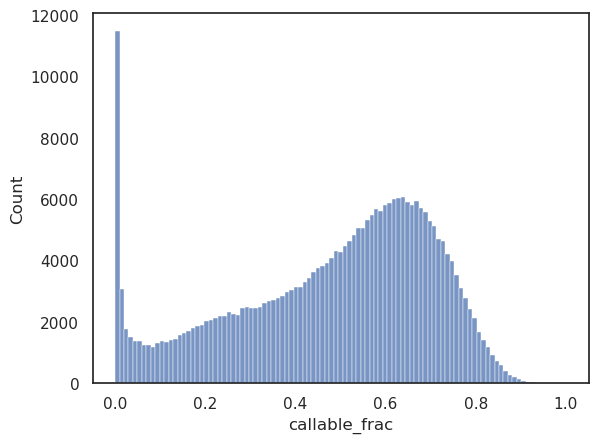

In [5]:
sns.histplot(bed_df, x="callable_frac")

In [6]:
pd.cut(bed_df.callable_frac, 10)

0         (-0.001, 0.1]
1            (0.2, 0.3]
2            (0.4, 0.5]
3            (0.7, 0.8]
4            (0.6, 0.7]
              ...      
285778       (0.1, 0.2]
285779    (-0.001, 0.1]
285780    (-0.001, 0.1]
285781    (-0.001, 0.1]
285782    (-0.001, 0.1]
Name: callable_frac, Length: 285783, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 0.1] < (0.1, 0.2] < (0.2, 0.3] < (0.3, 0.4] ... (0.6, 0.7] < (0.7, 0.8] < (0.8, 0.9] < (0.9, 1.0]]

<Axes: xlabel='cut', ylabel='pi'>

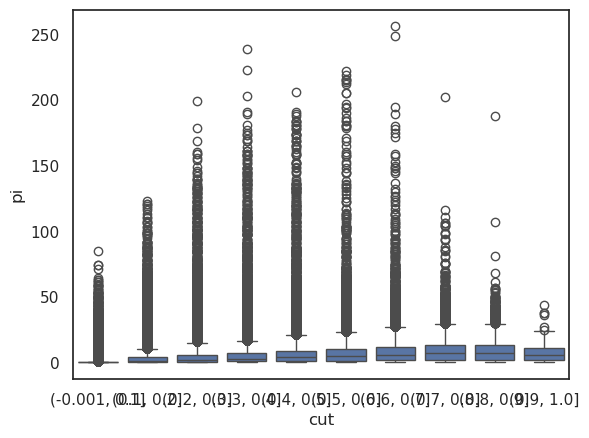

In [12]:
bed_df["cut"] = pd.cut(bed_df.callable_frac, 10)
sns.boxplot(bed_df, x="cut", y="pi")

/tmp/30151413/ipykernel_2748126/2912367716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trimmed_adj["cut"] = pd.cut(trimmed_adj.callable_frac, 10)
/tmp/30151413/ipykernel_2748126/2912367716.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trimmed_adj["pi_adj"] = trimmed_adj.pi/trimmed_adj.callable_frac


<Axes: xlabel='cut', ylabel='pi_adj'>

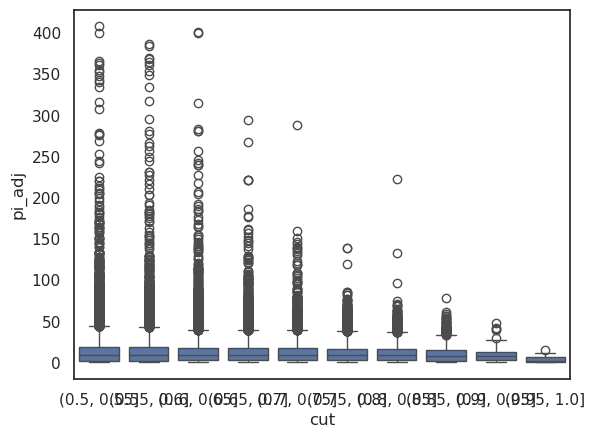

In [8]:
trimmed_adj = bed_df.loc[bed_df.callable_frac >= 0.5]
trimmed_adj["cut"] = pd.cut(trimmed_adj.callable_frac, 10)
trimmed_adj["pi_adj"] = trimmed_adj.pi/trimmed_adj.callable_frac
sns.boxplot(trimmed_adj, x="cut", y="pi_adj")

In [9]:
trimmed_adj.groupby(["cut"])[["pi"]].mean()

/tmp/30151413/ipykernel_2748126/2317724764.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trimmed_adj.groupby(["cut"])[["pi"]].mean()


,pi
cut,
"(0.5, 0.55]",7.240364
"(0.55, 0.6]",7.569295
"(0.6, 0.65]",7.924725
"(0.65, 0.7]",8.246969
"(0.7, 0.75]",8.718130
"(0.75, 0.8]",8.996078
"(0.8, 0.85]",9.080733
"(0.85, 0.9]",9.040581
"(0.9, 0.95]",8.245283


In [10]:
trimmed_adj.groupby(["cut"])[["pi_adj"]].mean()

/tmp/30151413/ipykernel_2748126/3183431587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trimmed_adj.groupby(["cut"])[["pi_adj"]].mean()


,pi_adj
cut,
"(0.5, 0.55]",13.779999
"(0.55, 0.6]",13.157089
"(0.6, 0.65]",12.683138
"(0.65, 0.7]",12.228914
"(0.7, 0.75]",12.049502
"(0.75, 0.8]",11.652463
"(0.8, 0.85]",11.066556
"(0.85, 0.9]",10.424695
"(0.9, 0.95]",9.007446


In [11]:
bed_df.loc[(bed_df.callable_frac >= 0.75)]["pi"].mean()

9.014262302343093

Checking the lifted version of the bed - much more fragmented.

In [13]:
bed_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi.bed".format("Arctocebus_calabarensis_ssp")
long_form = bed_path.split("/")[-1].split("_10kb")[0]
bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)

In [14]:
bed_df["window_size"] = bed_df.window_end-bed_df.window_start

In [15]:
bed_df.loc[bed_df.window_size >= 5000]

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac,window_size
759336,NC_060928.1,128618684,128623904,aut:0.8121,0.0,aut,0.8121,5220
15178456,NC_060926.1,179013635,179018660,aut:0.9779,0.0,aut,0.9779,5025
15178647,NC_060926.1,179042069,179048431,aut:0.9682,2.0,aut,0.9682,6362
15178648,NC_060926.1,179048431,179058431,aut:0.9997,0.0,aut,0.9997,10000
29038130,NC_060937.1,22537821,22545729,aut:0.9669,6.0,aut,0.9669,7908


In [19]:
# Number of bases from chrX lifted to human coordinates and chrX
bed_df.loc[(bed_df.chr_type == "chrX") & (bed_df.chrom == "NC_060947.1")].window_size.sum()

53145110

In [20]:
# Number of bases from chrX lifted to human coordinates and not chrX
bed_df.loc[(bed_df.chr_type == "chrX") & (bed_df.chrom != "NC_060947.1")].window_size.sum()

2183350

In [21]:
2183350/53145110

0.04108280140919832

Annotation/windowing workflow.

In [99]:
interval_size = 100*1000
bed_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi.bed".format("Arctocebus_calabarensis_ssp")
bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)
CAT_Genes = pd.read_csv("../data/hs1_CATGenes.bed", sep="\t")
protein_coding = CAT_Genes.loc[CAT_Genes.geneType == "protein_coding"]
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_numbers = ["chrX" if i == 22 else "chr{}".format(i+1) for i in range(len(chr_names))]

df_l = []
for c_n, c_i in zip(chr_names[:1], chr_numbers[:1]):
    print(c_i)
    chr_genes = protein_coding.loc[protein_coding["#chrom"] == c_i].copy()
    chr_df = bed_df.loc[bed_df.chrom == c_n].copy()
    sorted_df = chr_df.loc[chr_df.callable_frac >= 0.5].sort_values(by="window_start")
    sorted_df["bin"] = pd.cut(sorted_df.midpoint, list(range(0, sorted_df.window_end.iloc[-1]+interval_size,
                                                             interval_size)))

/tmp/30151413/ipykernel_2748126/2687372320.py:6: DtypeWarning: Columns (23,36) have mixed types. Specify dtype option on import or set low_memory=False.
  CAT_Genes = pd.read_csv("../data/hs1_CATGenes.bed", sep="\t")


chr1


In [197]:
bed_df

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac
0,NC_060928.1,70991253,70991286,aut:0.6625,2.0,aut,0.6625
1,NC_060928.1,70991289,70991401,aut:0.6625,2.0,aut,0.6625
2,NC_060928.1,70992370,70992440,aut:0.6625,2.0,aut,0.6625
3,NC_060928.1,70992440,70992462,aut:0.6625,2.0,aut,0.6625
4,NC_060928.1,70992463,70992549,aut:0.6625,2.0,aut,0.6625
...,...,...,...,...,...,...,...
39209794,NC_060926.1,230536839,230536870,aut:0.0703,0.0,aut,0.0703
39209795,NC_060926.1,230536870,230536873,aut:0.0703,0.0,aut,0.0703
39209796,NC_060926.1,230536873,230536905,aut:0.0703,0.0,aut,0.0703
39209797,NC_060926.1,230537364,230537377,aut:0.0703,0.0,aut,0.0703


In [190]:
df_l = []
for c_n, c_i in zip(chr_names[:2], chr_numbers[:2]):
    print(c_i)
    chr_genes = protein_coding.loc[protein_coding["#chrom"] == c_i].copy()
    chr_df = bed_df.loc[bed_df.chrom == c_n].copy()
    sorted_df = chr_df.loc[(chr_df.callable_frac >= 0.5) & (~chr_df.pi.isna())].sort_values(by="window_start")
    sorted_df["window_size"] = sorted_df.window_end-sorted_df.window_start
    sorted_df["midpoint"] = sorted_df["window_size"]/2+sorted_df.window_start
    sorted_df["pi_window"] = sorted_df.pi*sorted_df.window_size/10000 # Weighting it
    sorted_df["window_100kb"] = pd.cut(sorted_df.midpoint, list(range(0, sorted_df.window_end.iloc[-1]+interval_size,
                                                             interval_size)), labels=False)*interval_size
    summed_pi = (sorted_df.groupby(["chrom", "window_100kb"])[["pi_window"]].sum()).reset_index()
    summed_pi["mapped_bases"] = sorted_df.groupby(["window_100kb"])[["window_size"]].sum().reset_index()["window_size"]
    summed_pi["pi_per_mapped_base"] = summed_pi.pi_window/summed_pi.mapped_bases
    genes_l, max_genes_l, largest_gene_l, largest_gene_cov_l = [], [], [], []
    for w_s in summed_pi.window_100kb:
        w_e = w_s+interval_size
        overlapping_bed = chr_genes.loc[(chr_genes.thickStart <= w_e) & (chr_genes.thickEnd >= w_s)].copy()
        genes = overlapping_bed.name2.unique()
        if len(genes) >= 1:
            overlapping_bed["clipped_start"] = overlapping_bed.thickStart.clip(w_s, w_e)
            overlapping_bed["clipped_end"] = overlapping_bed.thickEnd.clip(w_s, w_e)
            overlapping_bed["feature_length"] = overlapping_bed.clipped_end-overlapping_bed.clipped_start
            sorted_max = overlapping_bed.groupby(["name2"])[["feature_length"]].max().sort_values(by="feature_length",
                                                                                     ascending=False).reset_index()
            genes_l.append(sorted_max.name2.values)
            max_genes_l.append(len(sorted_max.loc[sorted_max.feature_length >= w_e-w_s]))
            largest_gene_l.append(sorted_max.iloc[0].name2)
            largest_gene_cov_l.append(sorted_max.iloc[0].feature_length/(w_e-w_s))
        else:
            genes_l.append(np.nan)
            max_genes_l.append(0)
            largest_gene_l.append(np.nan)
            largest_gene_cov_l.append(0)
    summed_pi["genes"] = genes_l
    summed_pi["max_genes"] = max_genes_l
    summed_pi["largest_gene"] = largest_gene_l
    summed_pi["largest_gene_cov"] = largest_gene_cov_l
    df_l.append(summed_pi)
annotated_df = pd.concat(df_l)

chr1
chr2


In [192]:
annotated_df.loc[annotated_df.mapped_bases >= 25000]

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov
3,NC_060925.1,300000,1.4702,33478,0.000044,"[SAMD11, NOC2L, PLEKHN1, KLHL17]",0,SAMD11,0.17321
4,NC_060925.1,400000,4.9506,38374,0.000129,"[AGRN, PERM1, PLEKHN1, HES4, ISG15]",0,AGRN,0.34747
5,NC_060925.1,500000,2.1469,26184,0.000082,"[C1orf159, RNF223]",0,C1orf159,0.08652
6,NC_060925.1,600000,0.0000,27542,0.000000,"[TTLL10, UBE2J2, SDF4, C1QTNF12, TNFRSF18, TNF...",0,TTLL10,0.18416
7,NC_060925.1,700000,4.8006,44357,0.000108,"[ACAP3, SCNN1D, DVL1, INTS11, MXRA8, TAS1R3, P...",0,ACAP3,0.14275
...,...,...,...,...,...,...,...,...,...
2322,NC_060926.1,241400000,57.5444,55245,0.001042,"[CROCC2, SNED1]",0,CROCC2,0.86296
2323,NC_060926.1,241500000,19.4356,35249,0.000551,"[SNED1, MTERF4]",0,SNED1,0.87504
2324,NC_060926.1,241600000,24.5727,25218,0.000974,"[PASK, PPP1R7, ANO7, MTERF4]",0,PASK,0.36457
2327,NC_060926.1,241900000,8.5979,27954,0.000308,"[FARP2, STK25, MSTRG.3423]",0,FARP2,0.93462


<Axes: xlabel='mapped_bases', ylabel='pi_per_mapped_base'>

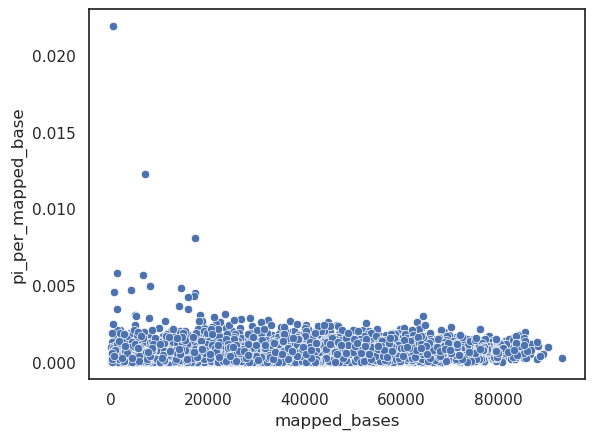

In [193]:
sns.scatterplot(annotated_df, x="mapped_bases", y="pi_per_mapped_base")

<Axes: xlabel='cut', ylabel='pi_per_mapped_base'>

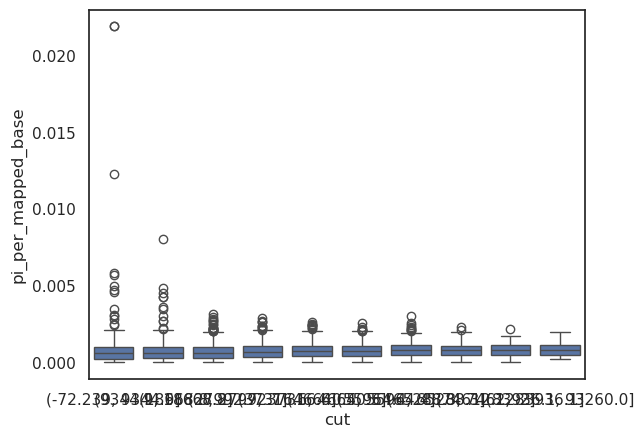

In [194]:
annotated_df["cut"] = pd.cut(annotated_df.mapped_bases, 10)
sns.boxplot(annotated_df, x="cut", y="pi_per_mapped_base")

In [136]:
summed_pi

,pi
bin,
"(0, 100000]",10.101124
"(100000, 200000]",1.000000
"(200000, 300000]",9.783784
"(300000, 400000]",0.499171
"(400000, 500000]",1.351779
...,...
"(247900000, 248000000]",NaN
"(248000000, 248100000]",37.232179
"(248100000, 248200000]",0.109890


In [135]:
sorted_df["pi_size"] = sorted_df.pi*sorted_df.window_size/10000
sorted_df

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac,window_size,midpoint,bin,pi_size
20170203,NC_060925.1,38173,38192,aut:0.5653,11.0,aut,0.5653,19,38182.5,"(0, 100000]",0.0209
20170200,NC_060925.1,38192,38214,aut:0.5653,11.0,aut,0.5653,22,38203.0,"(0, 100000]",0.0242
20170193,NC_060925.1,38541,38571,aut:0.5653,11.0,aut,0.5653,30,38556.0,"(0, 100000]",0.0330
20170186,NC_060925.1,38572,38584,aut:0.5653,11.0,aut,0.5653,12,38578.0,"(0, 100000]",0.0132
20170179,NC_060925.1,38584,38726,aut:0.5653,11.0,aut,0.5653,142,38655.0,"(0, 100000]",0.1562
...,...,...,...,...,...,...,...,...,...,...,...
34428137,NC_060925.1,248360024,248360059,aut:0.5275,18.0,aut,0.5275,35,248360041.5,"(248300000, 248400000]",0.0630
34428139,NC_060925.1,248360087,248360114,aut:0.5275,18.0,aut,0.5275,27,248360100.5,"(248300000, 248400000]",0.0486
34428141,NC_060925.1,248360114,248360128,aut:0.5275,18.0,aut,0.5275,14,248360121.0,"(248300000, 248400000]",0.0252
34428143,NC_060925.1,248360128,248360131,aut:0.5275,18.0,aut,0.5275,3,248360129.5,"(248300000, 248400000]",0.0054


In [123]:
sorted_df["pi"]

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac,window_size,midpoint,bin
33208454,NC_060925.1,27796,27808,aut:0.7993,NaN,aut,0.7993,12,27802.0,"(0, 100000]"
33208450,NC_060925.1,27808,27834,aut:0.7993,NaN,aut,0.7993,26,27821.0,"(0, 100000]"
33208443,NC_060925.1,28221,28269,aut:0.7993,NaN,aut,0.7993,48,28245.0,"(0, 100000]"
33208439,NC_060925.1,28270,28281,aut:0.7993,NaN,aut,0.7993,11,28275.5,"(0, 100000]"
33208436,NC_060925.1,28281,28389,aut:0.7993,NaN,aut,0.7993,108,28335.0,"(0, 100000]"
...,...,...,...,...,...,...,...,...,...,...
34428137,NC_060925.1,248360024,248360059,aut:0.5275,18.0,aut,0.5275,35,248360041.5,"(248300000, 248400000]"
34428139,NC_060925.1,248360087,248360114,aut:0.5275,18.0,aut,0.5275,27,248360100.5,"(248300000, 248400000]"
34428141,NC_060925.1,248360114,248360128,aut:0.5275,18.0,aut,0.5275,14,248360121.0,"(248300000, 248400000]"
34428143,NC_060925.1,248360128,248360131,aut:0.5275,18.0,aut,0.5275,3,248360129.5,"(248300000, 248400000]"


In [126]:
sorted_df.groupby(["bin"])

/tmp/30151413/ipykernel_2748126/1452455729.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sorted_df.groupby(["bin"])


In [29]:
# Some checks of the chrom df
chr_df.loc[chr_df.callable_frac >= 0.5]

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac
1051392,NC_060925.1,224474916,224474942,aut:0.631,3.0,aut,0.6310
1051393,NC_060925.1,224474942,224474957,aut:0.631,3.0,aut,0.6310
1051395,NC_060925.1,224474967,224474995,aut:0.631,3.0,aut,0.6310
1051397,NC_060925.1,224474995,224475004,aut:0.631,3.0,aut,0.6310
1051401,NC_060925.1,224475043,224475082,aut:0.631,3.0,aut,0.6310
...,...,...,...,...,...,...,...
39194450,NC_060925.1,159693254,159693329,chrX:0.5913,0.0,chrX,0.5913
39194453,NC_060925.1,159693331,159693354,chrX:0.5913,0.0,chrX,0.5913
39194456,NC_060925.1,159693355,159693368,chrX:0.5913,0.0,chrX,0.5913
39194457,NC_060925.1,159693368,159693385,chrX:0.5913,0.0,chrX,0.5913


In [52]:
sorted_df = chr_df.loc[chr_df.callable_frac >= 0.5].sort_values(by="window_start")

In [92]:
sorted_df

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac
33208454,NC_060925.1,27796,27808,aut:0.7993,NaN,aut,0.7993
33208450,NC_060925.1,27808,27834,aut:0.7993,NaN,aut,0.7993
33208443,NC_060925.1,28221,28269,aut:0.7993,NaN,aut,0.7993
33208439,NC_060925.1,28270,28281,aut:0.7993,NaN,aut,0.7993
33208436,NC_060925.1,28281,28389,aut:0.7993,NaN,aut,0.7993
...,...,...,...,...,...,...,...
34428137,NC_060925.1,248360024,248360059,aut:0.5275,18.0,aut,0.5275
34428139,NC_060925.1,248360087,248360114,aut:0.5275,18.0,aut,0.5275
34428141,NC_060925.1,248360114,248360128,aut:0.5275,18.0,aut,0.5275
34428143,NC_060925.1,248360128,248360131,aut:0.5275,18.0,aut,0.5275


In [93]:
sorted_df.loc[(sorted_df.window_start < sorted_df.window_end[:].shift(1))]

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac
26818513,NC_060925.1,3279415,3279483,aut:0.6333,40.0,aut,0.6333
35948725,NC_060925.1,3279469,3279494,aut:0.5261,5.0,aut,0.5261
26818514,NC_060925.1,3279486,3279494,aut:0.6333,40.0,aut,0.6333
26818515,NC_060925.1,3279494,3279526,aut:0.6333,40.0,aut,0.6333
26818516,NC_060925.1,3279538,3279568,aut:0.6333,40.0,aut,0.6333
...,...,...,...,...,...,...,...
34431022,NC_060925.1,248094538,248094569,aut:0.6163,28.0,aut,0.6163
34431207,NC_060925.1,248094553,248094569,aut:0.6313,72.0,aut,0.6313
34431025,NC_060925.1,248094580,248094610,aut:0.6163,28.0,aut,0.6163
34431202,NC_060925.1,248094612,248094629,aut:0.6313,72.0,aut,0.6313


In [98]:
sorted_df.loc[(sorted_df.window_start >= 3279415-100) & (sorted_df.window_end <= 3279483+100)]

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac
35948724,NC_060925.1,3279413,3279468,aut:0.5261,5.0,aut,0.5261
26818513,NC_060925.1,3279415,3279483,aut:0.6333,40.0,aut,0.6333
35948725,NC_060925.1,3279469,3279494,aut:0.5261,5.0,aut,0.5261
26818514,NC_060925.1,3279486,3279494,aut:0.6333,40.0,aut,0.6333
35948726,NC_060925.1,3279494,3279537,aut:0.5261,5.0,aut,0.5261
26818515,NC_060925.1,3279494,3279526,aut:0.6333,40.0,aut,0.6333
35948727,NC_060925.1,3279537,3279568,aut:0.5261,5.0,aut,0.5261
26818516,NC_060925.1,3279538,3279568,aut:0.6333,40.0,aut,0.6333
26818517,NC_060925.1,3279569,3279574,aut:0.6333,40.0,aut,0.6333
35948728,NC_060925.1,3279569,3279574,aut:0.5261,5.0,aut,0.5261


In [22]:
interval_size = 100*1000
bed_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi.bed".format("Arctocebus_calabarensis_ssp")
bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)
CAT_Genes = pd.read_csv("../data/hs1_CATGenes.bed", sep="\t")
protein_coding = CAT_Genes.loc[CAT_Genes.geneType == "protein_coding"]
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_numbers = ["chrX" if i == 22 else "chr{}".format(i+1) for i in range(len(chr_names))]

df_l = []
for c_n, c_i in zip(chr_names[:1], chr_numbers[:1]):
    print(c_i)
    chr_genes = protein_coding.loc[protein_coding["#chrom"] == c_i].copy()
    chr_df = bed_df.loc[bed_df.chrom == c_n].copy()
    if len(chr_df) == 0:
        print("Skipping due to no data")
        continue
    chr_df["window_size"] = chr_df.window_end-chr_df.window_start
    chr_df["midpoint"] = (chr_df.window_end-chr_df.window_start)/2+chr_df.window_start
    # This windowing procedure only makes sense if windows larger than 100kb are filtered out, but I will do that.
    chr_df["window_{}kb".format(args.w)] = (pd.cut(chr_df["midpoint"],
                                     np.arange(0, chr_df.window_end.max()+interval_size, interval_size),
                                     labels=False).values)*interval_size
    genes_l, max_genes_l, largest_gene_l, largest_gene_cov_l = [], [], [], []
    for w_s, w_e in zip(chr_df.window_start, chr_df.window_end):
        overlapping_bed = chr_genes.loc[(chr_genes.thickStart <= w_e) & (chr_genes.thickEnd >= w_s)].copy()
        genes = overlapping_bed.name2.unique()
        if len(genes) >= 1:
            overlapping_bed["clipped_start"] = overlapping_bed.thickStart.clip(w_s, w_e)
            overlapping_bed["clipped_end"] = overlapping_bed.thickEnd.clip(w_s, w_e)
            overlapping_bed["feature_length"] = overlapping_bed.clipped_end-overlapping_bed.clipped_start
            sorted_max = overlapping_bed.groupby(["name2"])[["feature_length"]].max().sort_values(by="feature_length",
                                                                                     ascending=False).reset_index()
            genes_l.append(sorted_max.name2.values)
            max_genes_l.append(len(sorted_max.loc[sorted_max.feature_length >= w_e-w_s]))
            largest_gene_l.append(sorted_max.iloc[0].name2)
            largest_gene_cov_l.append(sorted_max.iloc[0].feature_length/(w_e-w_s))
        else:
            genes_l.append(np.nan)
            max_genes_l.append(0)
            largest_gene_l.append(np.nan)
            largest_gene_cov_l.append(0)
    chr_df["genes"] = genes_l
    chr_df["max_genes"] = max_genes_l
    chr_df["largest_gene"] = largest_gene_l
    chr_df["largest_gene_cov"] = largest_gene_cov_l
    df_l.append(chr_df)
annotated_df = pd.concat(df_l)

/tmp/30151413/ipykernel_2748126/1269313829.py:4: DtypeWarning: Columns (23,36) have mixed types. Specify dtype option on import or set low_memory=False.
  CAT_Genes = pd.read_csv("../data/hs1_CATGenes.bed", sep="\t")


chr1


AttributeError: 'DataFrame' object has no attribute 'chrom'